In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [43]:
import numpy as np

# Original observed data
observed_values = np.array([0.738506842, 0.6821647, 0.548055553, 0.657031841, 
                            0.768209941, 0.713502614, 0.637432309, 0.707281024, 
                            0.766125043, 0.648790514, 0.607454704, 0.710364527])

# Calculate the reference standard deviation (ref_std)
ref_std = np.std(observed_values)

print(f"Reference Standard Deviation (ref_std): {ref_std}")


Reference Standard Deviation (ref_std): 0.0628151533804075


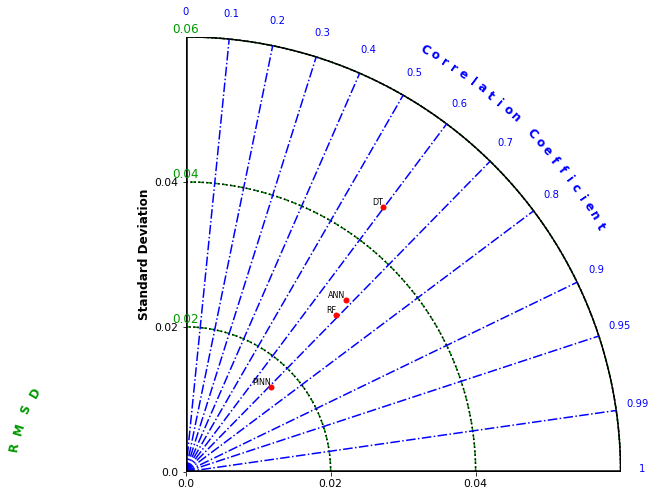

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import skill_metrics as sm

# Example data for models
stddevs = np.array([0.016580038, 0.032361389, 0.045488314, 0.02994123])  # Standard deviations of models
correlations = np.array([0.707613942, 0.681485943, 0.597647522, 0.691559131])  # Correlation coefficients
labels = ['Reference', 'PINN', 'ANN', 'DT', 'RF']  # Labels for the models and reference

# Reference standard deviation
ref_std = 0  # Standard deviation of the reference data (e.g., observations)

# Set CRMSD to zero (since we don't want to display it)
crmsd = np.zeros(len(stddevs))

# Combine the reference data into the arrays for Taylor diagram
sdev = np.concatenate(([ref_std], stddevs))  # Reference std as first element
ccoef = np.concatenate(([1], correlations))  # Reference correlation = 1 (perfect)
crmsd = np.concatenate(([0], crmsd))  # CRMSD is set to 0 for all data points

# Produce the Taylor diagram
fig = plt.figure(figsize=(8, 8))
sm.taylor_diagram(sdev, crmsd, ccoef, markerLabel=labels, markerLabelColor='black', markerSize=10)

# Show the plot
# plt.title('Taylor Diagram with Standard Deviation and Correlation Coefficient (No CRMSD)')
# plt.show()


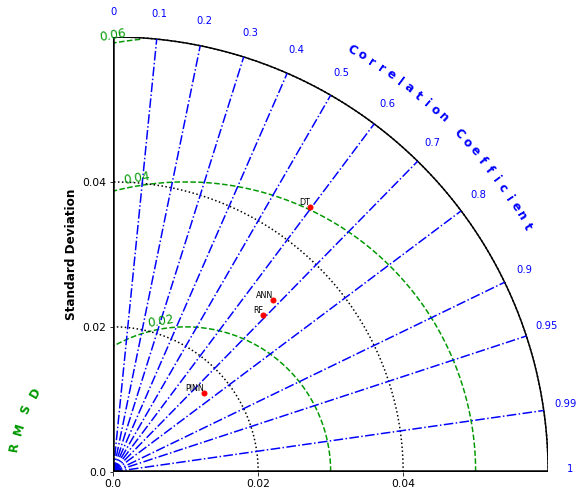

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import skill_metrics as sm

# Example data for models
stddevs = np.array([0.016580038, 0.032361389, 0.045488314, 0.02994123])  # Standard deviations of models
correlations = np.array([0.757613942, 0.681485943, 0.597647522, 0.691559131])  # Correlation coefficients
labels = ['PINN', 'ANN', 'DT', 'RF']  # Labels for the models

# Reference standard deviation
ref_std = 0.01  # Standard deviation of the reference data (e.g., observations)

# Compute CRMSD using the formula
crmsd = np.sqrt(stddevs**2 + ref_std**2 - 2 * stddevs * ref_std * correlations)

# Combine the reference data into the arrays for Taylor diagram
sdev = np.concatenate(([ref_std], stddevs))  # Reference std as the first element
ccoef = np.concatenate(([1], correlations))  # Reference correlation = 1 (perfect)
crmsd = np.concatenate(([0], crmsd))  # CRMSD of reference is 0

# Produce the Taylor diagram
fig = plt.figure(figsize=(8, 8))
dia = sm.taylor_diagram(sdev, crmsd, ccoef, markerLabel=['Reference'] + labels, markerLabelColor='black', markerSize=10)

# Remove the RMSD contours (green lines) manually by finding the plotted lines and removing them
ax = plt.gca()
for line in ax.get_lines():
    if line.get_color() == 'green':  # Assuming RMSD contours are green
        line.remove()

# Show the modified Taylor diagram
# plt.title('Taylor Diagram without RMSD Contours')
# plt.show()


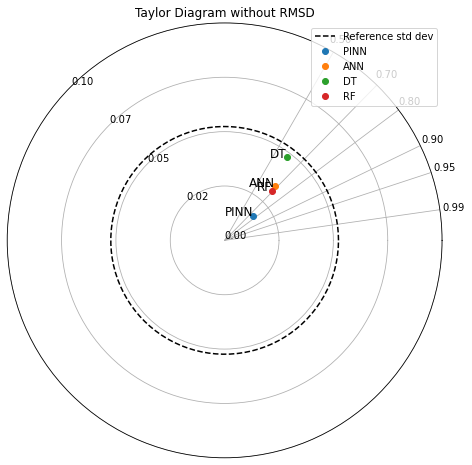

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Example data for models
stddevs = np.array([0.016580038, 0.032361389, 0.045488314, 0.02994123])  # Standard deviations of models
correlations = np.array([0.757613942, 0.681485943, 0.597647522, 0.691559131])  # Correlation coefficients
labels = ['PINN', 'ANN', 'DT', 'RF']  # Model labels

# Reference standard deviation
ref_std = 0.05  # Standard deviation of the reference data (e.g., observations)

# Create Taylor diagram manually
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Convert correlation to angles (radians)
angles = np.arccos(correlations)

# Plot reference standard deviation circle
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(theta, [ref_std] * 100, 'k--', label='Reference std dev')

# Plot model points
for i, (stddev, angle) in enumerate(zip(stddevs, angles)):
    ax.plot(angle, stddev, 'o', label=labels[i])

# Set the ticks for the correlation coefficient (angles)
ax.set_xticks(np.arccos([0.99, 0.95, 0.9, 0.8, 0.7, 0.5]))
ax.set_xticklabels(['0.99', '0.95', '0.90', '0.80', '0.70', '0.50'])

# Set radial grid (for standard deviation)
ax.set_rlabel_position(135)
ax.set_yticks(np.linspace(0, max(stddevs + [ref_std]), 5))
ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(0, max(stddevs + [ref_std]), 5)])

# Add labels for each model
for i, label in enumerate(labels):
    plt.text(angles[i], stddevs[i], label, fontsize=12, ha='right')

# Add title and show the plot
plt.title('Taylor Diagram without RMSD')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


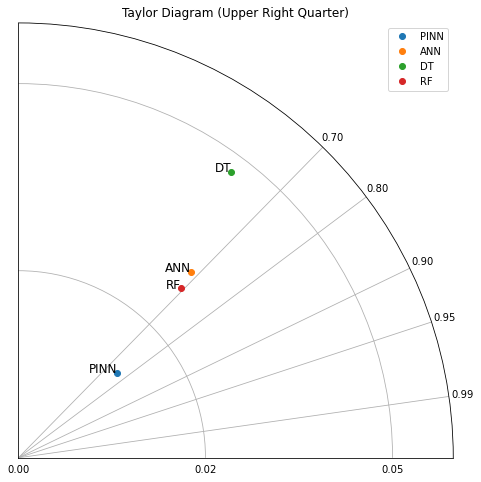

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Example data for models
stddevs = np.array([0.016580038, 0.032361389, 0.045488314, 0.02994123])  # Standard deviations of models
correlations = np.array([0.757613942, 0.681485943, 0.597647522, 0.691559131])  # Correlation coefficients
labels = ['PINN', 'ANN', 'DT', 'RF']  # Model labels

# Reference standard deviation
ref_std = 0.05  # Standard deviation of the reference data (e.g., observations)

# Create Taylor diagram manually (upper right quarter only)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Convert correlation to angles (radians)
angles = np.arccos(correlations)

# Plot reference standard deviation circle (quarter of it)
theta = np.linspace(0, np.pi / 2, 100)
# ax.plot(theta, [ref_std] * 100, 'k--', label='Reference std dev')

# Plot model points
for i, (stddev, angle) in enumerate(zip(stddevs, angles)):
    ax.plot(angle, stddev, 'o', label=labels[i])

# Set the ticks for the correlation coefficient (angles)
ax.set_xticks(np.arccos([0.99, 0.95, 0.9, 0.8, 0.7]))
ax.set_xticklabels(['0.99', '0.95', '0.90', '0.80', '0.70'])

# Set radial grid (for standard deviation)
ax.set_rlabel_position(135)
ax.set_yticks(np.linspace(0, max(stddevs + [ref_std]), 5))
ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(0, max(stddevs + [ref_std]), 5)])

# Limit plot to the upper right quarter
ax.set_ylim(0, max(stddevs) + 0.01)
ax.set_xlim(0, np.pi / 2)

# Add labels for each model
for i, label in enumerate(labels):
    plt.text(angles[i], stddevs[i], label, fontsize=12, ha='right')

# Add title and show the plot
plt.title('Taylor Diagram (Upper Right Quarter)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


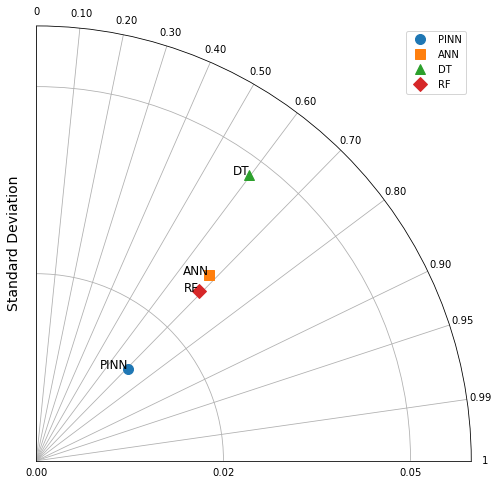

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Example data for models
stddevs = np.array([0.016580038, 0.032361389, 0.045488314, 0.02994123])  # Standard deviations of models
correlations = np.array([0.707613942, 0.681485943, 0.597647522, 0.691559131])  # Correlation coefficients
labels = ['PINN', 'ANN', 'DT', 'RF']  # Model labels

# Reference standard deviation
ref_std = 0.05  # Standard deviation of the reference data (e.g., observations)

# Different marker styles for each model
markers = ['o', 's', '^', 'D']  # circle, square, triangle up, diamond

# Create Taylor diagram manually (upper right quarter only)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Convert correlation to angles (radians)
angles = np.arccos(correlations)

# Plot reference standard deviation circle (quarter of it)
theta = np.linspace(0, np.pi / 2, 100)
# ax.plot(theta, [ref_std] * 100, 'k--', label='Reference std dev')

# Plot model points with different markers
for i, (stddev, angle, marker) in enumerate(zip(stddevs, angles, markers)):
    ax.plot(angle, stddev, marker, label=labels[i], markersize=10)

# Set the custom x-ticks for the correlation coefficient (angles from 0 to 1)
ax.set_xticks(np.arccos([1, 0.99, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0]))
ax.set_xticklabels(['1', '0.99', '0.95', '0.90', '0.80', '0.70', '0.60', '0.50', '0.40', '0.30', '0.20', '0.10', '0'])

# Set radial grid (for standard deviation)
ax.set_rlabel_position(135)
ax.set_yticks(np.linspace(0, max(stddevs + [ref_std]), 5))
ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(0, max(stddevs + [ref_std]), 5)])

# Limit plot to the upper right quarter
ax.set_ylim(0, max(stddevs) + 0.01)
ax.set_xlim(0, np.pi / 2)

# Add labels for each model
for i, label in enumerate(labels):
    plt.text(angles[i], stddevs[i], label, fontsize=12, ha='right')

    # Add y-axis label (Standard deviation)
ax.set_ylabel("Standard Deviation", fontsize=14)

# Add title and show the plot
# plt.title('Taylor Diagram (Upper Right Quarter) with Different Markers')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


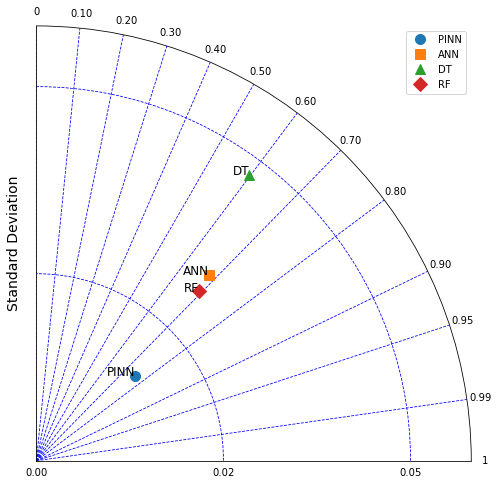

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Example data for models
stddevs = np.array([0.016580038, 0.032361389, 0.045488314, 0.02994123])  # Standard deviations of models
correlations = np.array([0.757613942, 0.681485943, 0.597647522, 0.691559131])  # Correlation coefficients
labels = ['PINN', 'ANN', 'DT', 'RF']  # Model labels

# Reference standard deviation
ref_std = 0.05  # Standard deviation of the reference data (e.g., observations)

# Different marker styles for each model
markers = ['o', 's', '^', 'D']  # circle, square, triangle up, diamond

# Create Taylor diagram manually (upper right quarter only)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Convert correlation to angles (radians)
angles = np.arccos(correlations)

# Plot reference standard deviation circle (quarter of it)
theta = np.linspace(0, np.pi / 2, 100)
# ax.plot(theta, [ref_std] * 100, 'k--', label='Reference std dev')

# Plot model points with different markers
for i, (stddev, angle, marker) in enumerate(zip(stddevs, angles, markers)):
    ax.plot(angle, stddev, marker, label=labels[i], markersize=10)

# Set the custom x-ticks for the correlation coefficient (angles from 0 to 1)
ax.set_xticks(np.arccos([1, 0.99, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0]))
ax.set_xticklabels(['1', '0.99', '0.95', '0.90', '0.80', '0.70', '0.60', '0.50', '0.40', '0.30', '0.20', '0.10', '0'])

# Set radial grid (for standard deviation) with blue dashed lines
ax.set_rlabel_position(135)
ax.set_yticks(np.linspace(0, max(stddevs + [ref_std]), 5))
ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(0, max(stddevs + [ref_std]), 5)])
ax.grid(True, linestyle='--', color='blue')  # Blue dashed lines

# Limit plot to the upper right quarter
ax.set_ylim(0, max(stddevs) + 0.01)
ax.set_xlim(0, np.pi / 2)

# Add labels for each model
for i, label in enumerate(labels):
    plt.text(angles[i], stddevs[i], label, fontsize=12, ha='right')

# Add y-axis label (Standard deviation)
ax.set_ylabel("Standard Deviation", fontsize=14)

# Add title and show the plot
# plt.title('Taylor Diagram (Upper Right Quarter) with Different Markers')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


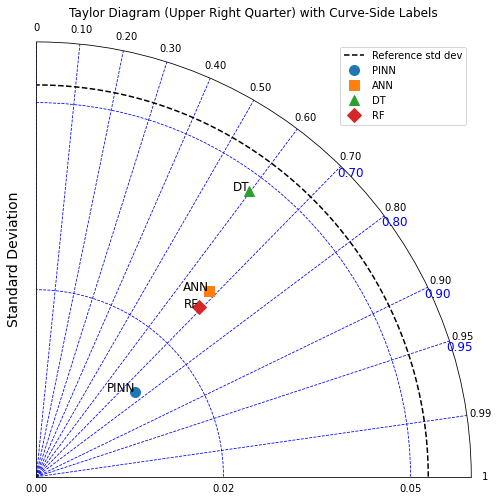

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Example data for models
stddevs = np.array([0.016580038, 0.032361389, 0.045488314, 0.02994123])  # Standard deviations of models
correlations = np.array([0.757613942, 0.681485943, 0.597647522, 0.691559131])  # Correlation coefficients
labels = ['PINN', 'ANN', 'DT', 'RF']  # Model labels

# Reference standard deviation
ref_std = 0.05  # Standard deviation of the reference data (e.g., observations)

# Different marker styles for each model
markers = ['o', 's', '^', 'D']  # circle, square, triangle up, diamond

# Create Taylor diagram manually (upper right quarter only)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Convert correlation to angles (radians)
angles = np.arccos(correlations)

# Plot reference standard deviation circle (quarter of it)
theta = np.linspace(0, np.pi / 2, 100)
ax.plot(theta, [ref_std] * 100, 'k--', label='Reference std dev')

# Plot model points with different markers
for i, (stddev, angle, marker) in enumerate(zip(stddevs, angles, markers)):
    ax.plot(angle, stddev, marker, label=labels[i], markersize=10)

# Set the custom x-ticks for the correlation coefficient (angles from 0 to 1)
ax.set_xticks(np.arccos([1, 0.99, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0]))
ax.set_xticklabels(['1', '0.99', '0.95', '0.90', '0.80', '0.70', '0.60', '0.50', '0.40', '0.30', '0.20', '0.10', '0'])

# Set radial grid (for standard deviation) with blue dashed lines
ax.set_rlabel_position(135)
ax.set_yticks(np.linspace(0, max(stddevs + [ref_std]), 5))
ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(0, max(stddevs + [ref_std]), 5)])
ax.grid(True, linestyle='--', color='blue')  # Blue dashed lines

# Limit plot to the upper right quarter
ax.set_ylim(0, max(stddevs) + 0.01)
ax.set_xlim(0, np.pi / 2)

# Add labels for each model
for i, label in enumerate(labels):
    plt.text(angles[i], stddevs[i], label, fontsize=12, ha='right')

# Add y-axis label (Standard Deviation)
ax.set_ylabel("Standard Deviation", fontsize=14)

# Add curve-side labels (for correlation)
ax.annotate("0.70", xy=(np.arccos(0.7), max(stddevs) + 0.01), xytext=(10, -10),
            textcoords='offset points', fontsize=12, color='blue', ha='center')
ax.annotate("0.80", xy=(np.arccos(0.8), max(stddevs) + 0.01), xytext=(10, -10),
            textcoords='offset points', fontsize=12, color='blue', ha='center')
ax.annotate("0.90", xy=(np.arccos(0.9), max(stddevs) + 0.01), xytext=(10, -10),
            textcoords='offset points', fontsize=12, color='blue', ha='center')
ax.annotate("0.95", xy=(np.arccos(0.95), max(stddevs) + 0.01), xytext=(10, -10),
            textcoords='offset points', fontsize=12, color='blue', ha='center')

# Add title and show the plot
plt.title('Taylor Diagram (Upper Right Quarter) with Curve-Side Labels')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


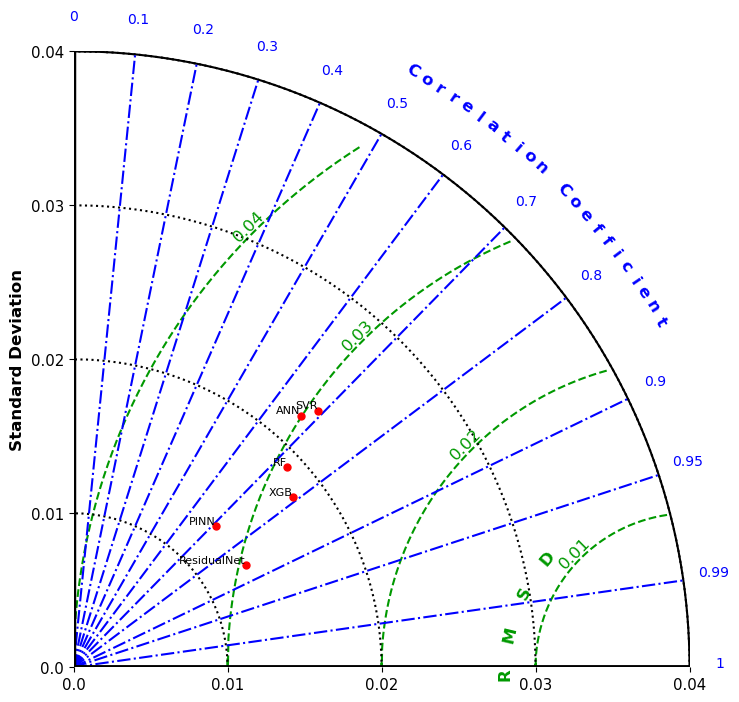

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import skill_metrics as sm

# Your data for models
# stddevs = np.array([0.10, 0.085, 0.075, 0.038, 0.018, 0.011])  # Standard deviations of models
# correlations = np.array([0.56, 0.61, 0.62, 0.76,0.69,  0.88])  # Correlation coefficients
# labels = ['reference','SVR', 'ANN', 'RF', 'XGB','PINN', 'ResidualNet']  # Model labels
stddevs = np.array([0.023, 0.022, 0.019, 0.018, 0.013, 0.013])  # Standard deviations of models
correlations = np.array([0.69, 0.67, 0.73, 0.79,0.71,  0.86])  # Correlation coefficients
labels = ['reference','SVR', 'ANN', 'RF', 'XGB','PINN', 'ResidualNet']  # Model labels

# Reference standard deviation (can be set to zero or 1 depending on normalization)
ref_std = 0.04  # Reference standard deviation

# Set CRMSD to zero (since we don't want to display it)
crmsd = np.zeros(len(stddevs))

# Combine the reference data into the arrays for Taylor diagram
sdev = np.concatenate(([ref_std], stddevs))  # Reference std as first element
ccoef = np.concatenate(([1], correlations))  # Reference correlation = 1 (perfect)
crmsd = np.concatenate(([0], crmsd))  # CRMSD is set to 0 for all data points

# Produce the Taylor diagram
fig = plt.figure(figsize=(8, 8))
sm.taylor_diagram(sdev, crmsd, ccoef, markerLabel=labels, markerLabelColor='black', markerSize=10)

# Show the plot
# plt.title('Taylor Diagram with Standard Deviation and Correlation Coefficient (No CRMSD)')
plt.show()


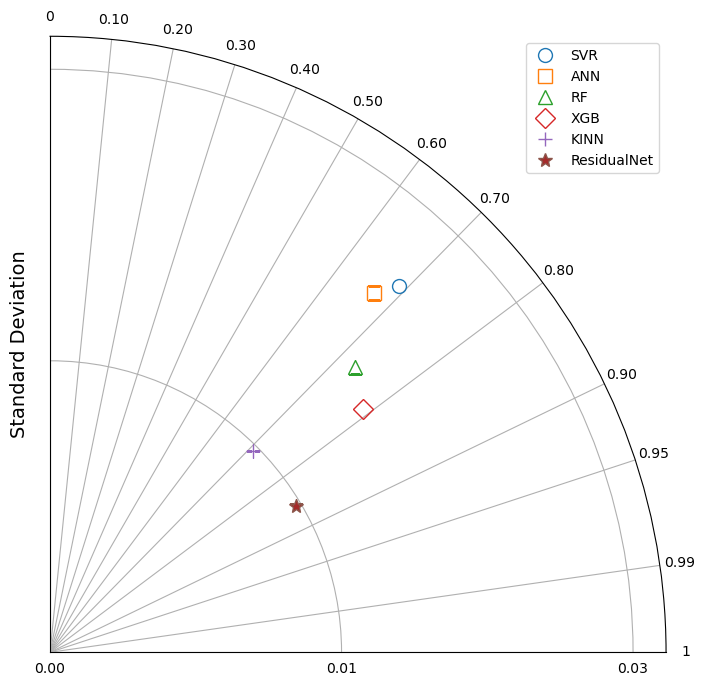

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Your data for models
stddevs = np.array([0.023, 0.022, 0.019, 0.018, 0.013, 0.013])  # Standard deviations of models
correlations = np.array([0.69, 0.67, 0.73, 0.79,0.71,  0.86])  # Correlation coefficients
labels = ['SVR', 'ANN', 'RF', 'XGB','KINN', 'ResidualNet']  # Model labels

# Reference standard deviation
ref_std = 0.03  # Standard deviation of the reference data (e.g., observations)

# Different marker styles for each model
markers = ['o', 's', '^', 'D','+', '*']  # circle, square, triangle up, diamond, star
markerfacecolors = ['none','none','none','none','none','brown']

# Create Taylor diagram manually (upper right quarter only)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Convert correlation to angles (radians)
angles = np.arccos(correlations)

# Plot model points with different markers
for i, (stddev, angle, marker) in enumerate(zip(stddevs, angles, markers)):
    ax.plot(angle, stddev, marker, label=labels[i], markersize=10, markerfacecolor=markerfacecolors[i])

# Set the custom x-ticks for the correlation coefficient (angles from 0 to 1)
ax.set_xticks(np.arccos([1, 0.99, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0]))
ax.set_xticklabels(['1', '0.99', '0.95', '0.90', '0.80', '0.70', '0.60', '0.50', '0.40', '0.30', '0.20', '0.10', '0'])

# Set radial grid (for standard deviation)
ax.set_rlabel_position(135)
ax.set_yticks(np.linspace(0, max(stddevs + [ref_std]), 5))
ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(0, max(stddevs + [ref_std]), 5)])

# Limit plot to the upper right quarter
ax.set_ylim(0, max(stddevs) + 0.005)
ax.set_xlim(0, np.pi / 2)



# # Add labels for each model
# for i, label in enumerate(labels):
#     plt.text(angles[i], stddevs[i], label, fontsize=8, ha='left')

# Add y-axis label (Standard deviation)
ax.set_ylabel("Standard Deviation", fontsize=14)

# Add title and show the plot
plt.legend(loc='upper right')
plt.grid(True)
# plt.show()
plt.savefig('taylor diagram1.png', dpi=300, bbox_inches='tight')


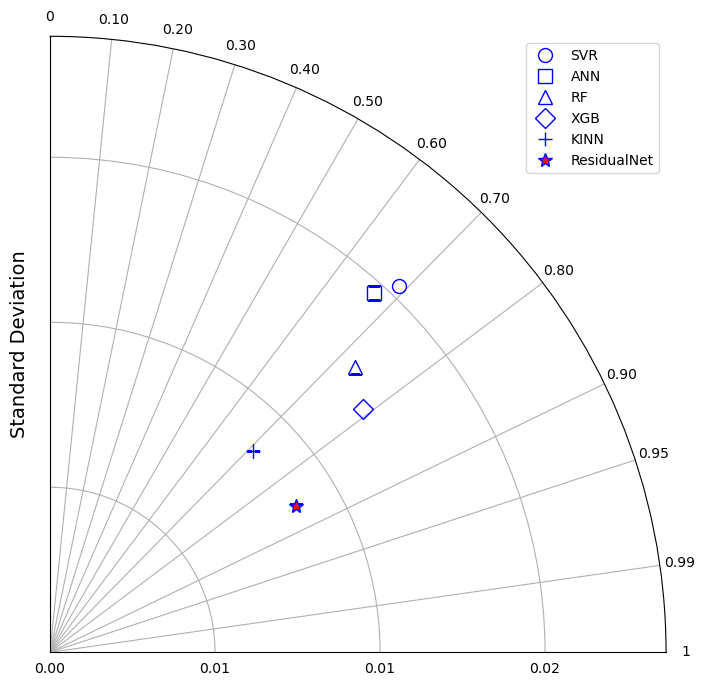

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Your data for models
stddevs = np.array([0.023, 0.022, 0.019, 0.018, 0.013, 0.013])  # Standard deviations of models
correlations = np.array([0.69, 0.67, 0.73, 0.79, 0.71, 0.86])  # Correlation coefficients
labels = ['SVR', 'ANN', 'RF', 'XGB', 'KINN', 'ResidualNet']  # Model labels

# Reference standard deviation
ref_std = 0.03  # Standard deviation of the reference data (e.g., observations)

# Different marker styles for each model
markers = ['o', 's', '^', 'D', '+', '*']  # circle, square, triangle up, diamond, plus, star
markerfacecolors = ['none', 'none', 'none', 'none', 'none', 'red']  # Red filled for ResidualNet, others hollow

# Create Taylor diagram manually (upper right quarter only)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Convert correlation to angles (radians)
angles = np.arccos(correlations)

# Plot model points with different markers and colors
for i, (stddev, angle, marker, markerfacecolor) in enumerate(zip(stddevs, angles, markers, markerfacecolors)):
    ax.plot(angle, stddev, marker, label=labels[i], markersize=10, 
            markerfacecolor=markerfacecolor, markeredgecolor='blue')

# Set the custom x-ticks for the correlation coefficient (angles from 0 to 1)
ax.set_xticks(np.arccos([1, 0.99, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0]))
ax.set_xticklabels(['1', '0.99', '0.95', '0.90', '0.80', '0.70', '0.60', '0.50', '0.40', '0.30', '0.20', '0.10', '0'])

# Set radial grid (for standard deviation)
ax.set_rlabel_position(135)
ax.set_yticks(np.linspace(0, max(np.append(stddevs, ref_std)), 5))
ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(0, max(np.append(stddevs, ref_std)), 5)])

# Limit plot to the upper right quarter
ax.set_ylim(0, max(stddevs) + 0.005)
ax.set_xlim(0, np.pi / 2)

# Add y-axis label (Standard deviation)
ax.set_ylabel("Standard Deviation", fontsize=14)

# Add title and show the plot
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig('taylor_diagram_with_colored_outliers.png', dpi=300, bbox_inches='tight')
